## Assignment 7 - Deadline: April 28, 2026, Tue 11pm

#### DSAI 541 Spring 2026

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.bogazici.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time and no late homeworks will be accepted.


To make a pdf, this may work if you're using Jupyter notebook on browser: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu. (You can use Google Colab, but at the end you should download the ipynb notebook to submit it on Moodle.)

In [3]:
# Run this cell first

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Set the display option to show all rows scrolling with a slider
pd.set_option('display.max_rows', None)
# To disable this, run the line below:
# pd.reset_option('display.max_rows')

<span style="color:red">Note: Training the LSTM model in Problem 2 may take long if you don't have GPU in your laptop. You can complete this assignment on Google Colab.</span>

# Problem 1: Star Prediction on YELP Reviews with Bag of Words Approach (50 pts)

The purpose of this assignment is to build a multiclass classification model that will predict the review stars (1-5) from the review text.

Yelp restaurant review data is loaded below. We're using a small version of the original dataset here to alleviate computational load on your machines. If you like, you can download the full dataset at https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset?resource=download&select=yelp_academic_dataset_review.json and download yelp_academic_dataset_review.json (5.34 GB), but this is not necessary for this assignment. 

The smaller version (500.000 reviews) of this dataset is available on the Moodle page of the class under the section Datasets. Download `small_yelp_academic_dataset_review.zip` and extract the json file. 

**Part a)** The dataset is loaded to the dataframe `df_imbalanced` below. The histogram below reveals class imbalance. The class 2-stars has the minimum number of records here. Downsample data from all other four classes so that all classes has the same number of records as the 2-stars class has. <br>

**Part b)** Divide data as train, val and test. Vectorize the text. You're free to use any Bag-of-Words approach like unigrams, bi-grams etc. (See the Jupyter notebooks accompanying lecture notes.) <br>

**Part c)** Train a fully connected feed forward artificial neural network classifier model that can predict 5 star classes from review text. Report accuracy on the test set and show 5x5 confusion matrix.

**Part d)** Print the text, `y` and `y_{pred}` for four different reviews that your model misclassified. Look at the text and interpret why the model might have misclassified these four reviews. What words from those reviews do you think led to misclassification?

#### Part a)

In [4]:
import pandas as pd

# Load the Yelp dataset
df_imbalanced = pd.read_json('../datasets/small_yelp_academic_dataset_review.json/small_yelp_academic_dataset_review.json', lines=True)

# Print the number of reviews
print(len(df_imbalanced))


500000


In [5]:
df_imbalanced.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


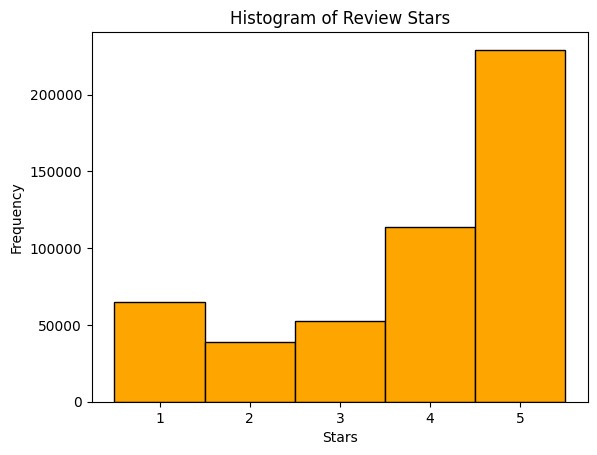

In [6]:
import matplotlib.pyplot as plt

# Plot histogram of the 'stars' column
plt.hist(df_imbalanced['stars'], bins=range(1, 7), align='left', color='orange', edgecolor='black')
plt.xlabel('Stars')
plt.ylabel('Frequency')
plt.title('Histogram of Review Stars')
plt.show()


In [7]:
def downsample_classd(df):
    min_class_label = df['stars'].value_counts().idxmin()
    num_samples_min_class = df['stars'].value_counts().min()
    down_sampled_dfs = []
    for class_label in range(1, 6):
        # Filter the DataFrame to get all rows with the specified class label
        class_data = df[df['stars'] == class_label]
        
        # Downsample the class data to the number of samples in the smallest class (which is 2 star in this case)
        downsampled_data = class_data.sample(n=num_samples_min_class, random_state=42)
        
        # Append the downsampled data to the list
        down_sampled_dfs.append(downsampled_data)
    
    # Concatenate all downsampled DataFrames
    df_downsampled = pd.concat(down_sampled_dfs, ignore_index=True)
    return df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle the downsampled DataFrame

In [8]:
downsampled_df = downsample_classd(df_imbalanced)
print(downsampled_df['stars'].value_counts())

stars
2    38856
4    38856
1    38856
3    38856
5    38856
Name: count, dtype: int64


In [9]:
downsampled_df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,9CETmvypoU8OTgjHm-hj0Q,uOlSbEAl2Cuy7yB0E5tn2A,SLmGshQmUoMPMlwbMuLWLQ,2,1,0,0,Drinks are very good. However we weren't the b...,2019-02-16 14:18:54
1,cupL5nwGtNZ5CEPkYpCzvQ,jN61n8zmPtyYScfug3VQgQ,jlgi2sLx5i6_t4mcODJW7A,2,0,0,0,Below Average! When a menu item states poached...,2015-05-25 16:21:22
2,6zzMxwWgTrrm4UmgaIOreA,ml-rDgT9FAz6G9UlpRPwIw,4oSBz4ug5LjxVn26DsQjUA,4,0,0,0,Really good food! Ordered the combo with jerk ...,2018-08-11 18:02:11
3,yociDM1oQ-WrqJ_RFuPajQ,hZ5QZ-50VlaKjyMCIhcUlA,vG9aD-fvsIimgo-l7u8-AA,4,0,0,0,"Consistant food quality, and usually great ser...",2012-12-26 22:46:17
4,yTVMZ8HkDJXQwOCD7ep45w,a0Si4lQ-HoKhJL41z3fZXQ,B6Lvq3sOYwhKxPzadDka9g,1,4,7,0,I am only giving one star because I have not t...,2012-04-01 17:13:42


#### Part b)

In [10]:
downsampled_df["target"] = downsampled_df["stars"]-1
X = downsampled_df["text"]
y = downsampled_df["target"]

# 0.5 for training, 0.25 for validation, and 0.25 for testing
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.5, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 3), smooth_idf=True, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
from torch.utils.data import Dataset
import torch

class SparseTextDataset(Dataset):
    def __init__(self, sparse_matrix, labels):
        self.sparse_matrix = sparse_matrix
        self.labels = labels.values
        
    def __len__(self):
        return self.sparse_matrix.shape[0]
    
    def __getitem__(self, idx):
        row_dense = self.sparse_matrix[idx].toarray().squeeze()

        x_tensor = torch.tensor(row_dense, dtype=torch.float32)
        y_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return x_tensor, y_tensor

In [14]:
train_dataset = SparseTextDataset(X_train_vec, y_train)
val_dataset = SparseTextDataset(X_val_vec, y_val)
test_dataset = SparseTextDataset(X_test_vec, y_test)

In [15]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


#### Part c)

In [16]:
class FCFFANN(torch.nn.Module):
    def __init__(self, input_dim):
        super(FCFFANN, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, 512)
        self.dropout1 = torch.nn.Dropout(0.3)
        self.fc2 = torch.nn.Linear(512, 256)
        self.dropout2 = torch.nn.Dropout(0.5)

        self.fc3 = torch.nn.Linear(256, 5)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x        

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
model = FCFFANN(input_dim=X_train_vec.shape[1]).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
import copy
def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler=None, num_epochs=100):
    best_val_loss = float("inf")
    delta = 1e-5
    best_model = copy.deepcopy(model.state_dict())
    last_improvement_epoch = 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        run_epoch_train_loss = 0
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits , y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            run_epoch_train_loss += loss.item()

        avg_train_loss = run_epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}", end='')

        # Validation phase
        model.eval()
        run_epoch_val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device) # Reshape to (batch_size, 1)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                run_epoch_val_loss += loss.item()

        avg_val_loss = run_epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f", Validation Loss: {avg_val_loss:.4f}")
        
        if scheduler is not None:
            scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss - delta:
            best_val_loss = avg_val_loss
            best_model = copy.deepcopy(model.state_dict())
            last_improvement_epoch = epoch
        elif epoch - last_improvement_epoch >= 4: # Stop if no improvement for 4 epochs
            print(f"Early stopping at epoch {epoch+1} with best validation loss: {best_val_loss:.4f}")
            break

    return train_losses, val_losses, best_val_loss, best_model, last_improvement_epoch

In [20]:
train_losses_1, val_losses_1, best_val_loss_1, best_model_1, last_improvement_epoch_1 = train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=10)

Epoch 1/10, Train Loss: 0.9374, Validation Loss: 0.8697
Epoch 2/10, Train Loss: 0.7597, Validation Loss: 0.8852
Epoch 3/10, Train Loss: 0.5814, Validation Loss: 0.9981
Epoch 4/10, Train Loss: 0.3061, Validation Loss: 1.3094
Epoch 5/10, Train Loss: 0.1308, Validation Loss: 1.8467
Early stopping at epoch 5 with best validation loss: 0.8697


In [ ]:
model = FCFFANN(input_dim=X_train_vec.shape[1]).to(device)
model.load_state_dict(best_model_1)
model.eval()

from sklearn.metrics import confusion_matrix, classification_report
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# Also calculate off by one accuracy
off_by_one_correct = sum(1 for true, pred in zip(all_labels, all_preds) if abs(true - pred) <= 1)
off_by_one_accuracy = off_by_one_correct / len(all_labels)
print(f"Off-by-One Accuracy: {off_by_one_accuracy:.4f}")


Confusion Matrix:
[[7273 2215  211   40   75]
 [1978 5574 1939  175   57]
 [ 356 2253 5327 1585  165]
 [  74  275 2014 5776 1456]
 [ 106   77  254 3296 6019]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      9814
           1       0.54      0.57      0.55      9723
           2       0.55      0.55      0.55      9686
           3       0.53      0.60      0.56      9595
           4       0.77      0.62      0.69      9752

    accuracy                           0.62     48570
   macro avg       0.63      0.62      0.62     48570
weighted avg       0.63      0.62      0.62     48570

Off-by-One Accuracy: 0.9616


In [ ]:
import numpy as np, random, torch, pandas as pd

def print_misclassified_examples(n=4, top_k=8, seed=42):
    random.seed(3407)
    # locate model and vectorizer
    model_used = globals().get('model_final', globals().get('model', None))
    vec = globals().get('vec_final', globals().get('vectorizer', None))
    if model_used is None:
        raise RuntimeError("No model found (model_final or model). Run training first.")
    if vec is None:
        raise RuntimeError("No vectorizer found (vec_final or vectorizer).")

    # get raw test texts
    if 'X_test' not in globals():
        raise RuntimeError("X_test not found in the notebook namespace.")
    X_test_texts = X_test.reset_index(drop=True) if hasattr(X_test, "reset_index") else pd.Series(list(X_test)).reset_index(drop=True)

    # compute predictions if needed
    if ('y_t' not in globals()) or ('y_p' not in globals()):
        if 'test_loader' not in globals():
            raise RuntimeError("test_loader not found; create a DataLoader for the test set first.")
        y_t_list, y_p_list = [], []
        model_used.eval()
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb = Xb.to(device)
                yb = yb.to(device)
                out = model_used(Xb)
                preds = torch.argmax(out, dim=1)
                y_p_list.extend(preds.cpu().numpy().tolist())
                y_t_list.extend(yb.cpu().numpy().tolist())
        y_t = np.array(y_t_list)
        y_p = np.array(y_p_list)
    else:
        y_t = np.array(globals()['y_t'])
        y_p = np.array(globals()['y_p'])

    # TF-IDF matrix and feature names for the test set
    X_test_vec = vec.transform(X_test_texts)
    try:
        feat_names = np.asarray(vec.get_feature_names_out())
    except AttributeError:
        feat_names = np.asarray(vec.get_feature_names())

    # find misclassified indices
    mis_idx = np.where(y_t != y_p)[0]
    if len(mis_idx) == 0:
        print("No misclassifications found on the test set.")
        return

    selected = random.sample(list(mis_idx), min(n, len(mis_idx)))
    for i, idx in enumerate(selected, 1):
        text = X_test_texts.iloc[idx]
        true_lbl = int(y_t[idx])+1
        pred_lbl = int(y_p[idx])+1

        # get TF-IDF row for this sample and extract top features
        row = X_test_vec[idx]
        row_arr = row.toarray().ravel() if hasattr(row, "toarray") else np.asarray(row).ravel()
        if row_arr.sum() == 0:
            top_features = []
        else:
            ord_idx = np.argsort(-row_arr)
            pos_ord = [j for j in ord_idx if row_arr[j] > 0]
            top_idx = pos_ord[:top_k]
            top_features = [(feat_names[j], float(row_arr[j])) for j in top_idx]

        print(f"--- Misclassified sample #{i} (global index {idx}) ---")
        print(f"True label: {true_lbl}, Predicted: {pred_lbl}")
        print("Text:")
        print(text)
        print("Top TF-IDF words (word, weight):")
        print(top_features)
        print()

# Example usage:
print_misclassified_examples(n=4, top_k=8)

--- Misclassified sample #1 (global index 4823) ---
True label: 5, Predicted: 4
Text:
I had a good experience here! The techs seemed to have enough knowledge, the service was fast, everyone was nice, and the main objective was completed: I got my oil changed. It's a bit pricy but I had a Groupon so it was half off. I think if I go next time I'll just stick with the conventional because that's still $42. Anyway, if you have a busy life and need appointment free oil changes/don't have time to do them yourself (such as me), go ahead and give this place a try.
Top TF-IDF words (word, weight):
[('oil', 0.1684226333788102), ('half off', 0.1431658332580334), ('this place try', 0.13970157011577788), ('life and', 0.13958471415120816), ('seemed to have', 0.1390110475516217), ('was half', 0.13856434792847583), ('time ll', 0.13823612786462358), ('service was fast', 0.1377014695012912)]

--- Misclassified sample #2 (global index 36144) ---
True label: 4, Predicted: 5
Text:
Best Chinese food I've ev

#### d) Why model misclassified sentences:

Let's check each misclassified example one by one:

* The top weighted tf-idf vectors for words "oil", "half off" which may have negative meaning in the training set also there are some potential positive vectors like "service was fast", "this place try". The values for those vectors are close top tf-idf vector has weight 0.16 and least one has weight 0.137. Model get the idea that the sentiment analyis would return positive but when deciding how positive, it failed.

* I think in this example the model classified well, but the labeling was not good, hence it classifed wrong if we assume labeling was true. Human annotators would also give this 5 star. No dataset is perfect.

* The sentence is long and model focused on wrong tf-idf vectors. However it still did a good job, I assume that it focused on words like "waiter", "the waiter", "for/? the check" and I think in the training corpus there were a lot of complaints about prices or waiters. And model use those words to classify this sentence with 2 stars.

* The words like great, enjoy may occur so much document in the corpus and tf-idf penalizes it for occuring in too many sentences. Because of that, the model may not give enough attention to these positive words and resulted in classifying it negative.

# Problem 2: Star Prediction on YELP Reviews with GloVe Embeddings and Bidirectional LSTM (50 pts)

Follow the same steps as Problem 1 but this time instead of bag-of-words model, build a Bidirectional LSTM model to predict the class.

The embedding vectors are available on the Moodle page of the class under the section Datasets. Download `glove.6B.100d.zip` and extract the txt file. 

**Part a)** Downsame as in the previous problem. <br>

**Part b)** Train a Bidirectional LSTM model with GloVe embeddings to predict 5 classes (5 different ratings from Yelp). You can use the code from Lecture_12.ipynb, but you need to modify the output layer so that it predicts 5 classes.<br>

**Part c)** Report test accuracy on the test set and produce 5x5 confusion matrix.

**Part d)** Print the text, $y$ and $y_{pred}$ for four different reviews that your model misclassified. Look at the text and interpret why the model might have misclassified these four reviews. What words from those reviews do you think led to misclassification?

#### Part a)

In [27]:
glove_embeddings_txt = '../datasets/glove.6B.100d.txt/glove.6B.100d.txt'
def load_glove_embeddings(glove_file_path, word_index, embedding_dim=100):
    embeddings_index = {}
    with open(glove_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
    for word, i in word_index.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

    return embedding_matrix

In [ ]:
from collections import Counter
import torch

def tokenize_and_pad(texts_train, texts_val, texts_test, max_length=200, max_vocab_size=30000):
    print("Building vocabulary from training data...")

    word_counts = Counter()
    for text in texts_train:
        words = str(text).lower().split()
        word_counts.update(words)
        
    word_index = {'<PAD>': 0, '<UNK>': 1}

    for idx, (word, count) in enumerate(word_counts.most_common(max_vocab_size), start=2):
        word_index[word] = idx
        
    print(f"Vocabulary built with {len(word_index)} unique tokens.")


    def convert_to_padded_sequence(text_list):
        sequences = []
        for text in text_list:
            words = str(text).lower().split()

            seq = [word_index.get(word, 1) for word in words]
            
            if len(seq) > max_length:
                seq = seq[:max_length]
            else:
                seq = seq + [0] * (max_length - len(seq))  
                
            sequences.append(seq)
            
        return torch.tensor(sequences, dtype=torch.long)
        
    print("Converting texts to padded integer sequences...")
    X_train_seq = convert_to_padded_sequence(texts_train)
    X_val_seq = convert_to_padded_sequence(texts_val)
    X_test_seq = convert_to_padded_sequence(texts_test)
    
    return X_train_seq, X_val_seq, X_test_seq, word_index

X_train_seq, X_val_seq, X_test_seq, word_index = tokenize_and_pad(
    X_train, 
    X_val, 
    X_test, 
    max_length=200
)

Building vocabulary from training data...
Vocabulary built with 30002 unique tokens.
Converting texts to padded integer sequences...


In [ ]:
from torch.utils.data import Dataset, DataLoader

class SequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = torch.tensor(labels.values, dtype=torch.long) 
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_dataset = SequenceDataset(X_train_seq, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
embedding_matrix = load_glove_embeddings(glove_embeddings_txt, word_index, embedding_dim=100)

val_dataset = SequenceDataset(X_val_seq, y_val)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, pin_memory=True)

test_dataset = SequenceDataset(X_test_seq, y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True)

#### Part b)

In [48]:
import torch
import torch.nn as nn

class BiLSTMClassifier(nn.Module):
    def __init__(self,
                 vocab_size,
                 embedding_dim=100,
                 hidden_dim=128,
                 num_classes=5,
                 embedding_matrix=None):
        super(BiLSTMClassifier, self).__init__()

        if embedding_matrix is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.FloatTensor(embedding_matrix),
                freeze=False,
                padding_idx=0
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(hidden_dim * 2 * 3 , 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        lengths = (x != 0).sum(dim=1).cpu()

        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths=lengths,
            batch_first=True,
            enforce_sorted=False
        )

        packed_out, (hidden, cell) = self.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))

        final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        mask = (x != 0).unsqueeze(-1)
        sum_pool = torch.sum(lstm_out * mask, dim=1)
        avg_pool = sum_pool / lengths.unsqueeze(1).to(lstm_out.dtype)

        max_pool, _ = torch.max(lstm_out.masked_fill(~mask, float("-inf")), dim=1)

        features = torch.cat((final_hidden, avg_pool, max_pool), dim=1)

        out = self.dropout(features)
        out = torch.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)

        return out

In [46]:
model = BiLSTMClassifier(
    vocab_size=len(word_index),
    embedding_dim=100,
    hidden_dim=128,
    num_classes=5,
    embedding_matrix=embedding_matrix
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = torch.nn.CrossEntropyLoss()

train_losses_2, val_losses_2, best_val_loss_2, best_model_2, last_improvement_epoch_2 = train_model(model, train_loader, val_loader, optimizer, criterion, scheduler=scheduler, num_epochs=20)


Epoch 1/20, Train Loss: 1.1491, Validation Loss: 1.0208
Epoch 2/20, Train Loss: 0.9188, Validation Loss: 0.9166
Epoch 3/20, Train Loss: 0.8346, Validation Loss: 0.9101
Epoch 4/20, Train Loss: 0.7668, Validation Loss: 0.9204
Epoch 5/20, Train Loss: 0.7048, Validation Loss: 0.9762
Epoch 6/20, Train Loss: 0.6500, Validation Loss: 1.0060
Epoch 7/20, Train Loss: 0.5607, Validation Loss: 1.1498
Early stopping at epoch 7 with best validation loss: 0.9101


#### Part c)

In [47]:
model =  BiLSTMClassifier(
    vocab_size=len(word_index),
    embedding_dim=100,
    hidden_dim=128,
    num_classes=5,
    embedding_matrix=embedding_matrix
).to(device)
model.load_state_dict(best_model_2)
model.eval()

# Evaluate on the test set and build confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# Also calculate off by one accuracy
off_by_one_correct = sum(1 for true, pred in zip(all_labels, all_preds) if abs(true - pred) <= 1)
off_by_one_accuracy = off_by_one_correct / len(all_labels)
print(f"Off-by-One Accuracy: {off_by_one_accuracy:.4f}")


Confusion Matrix:
[[7628 1960  137   39   50]
 [2379 5794 1349  154   47]
 [ 462 3241 4280 1539  164]
 [ 107  510 2039 5185 1754]
 [ 174  132  333 2814 6299]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      9814
           1       0.50      0.60      0.54      9723
           2       0.53      0.44      0.48      9686
           3       0.53      0.54      0.54      9595
           4       0.76      0.65      0.70      9752

    accuracy                           0.60     48570
   macro avg       0.60      0.60      0.60     48570
weighted avg       0.61      0.60      0.60     48570

Off-by-One Accuracy: 0.9525


In [42]:

import numpy as np, random, torch, pandas as pd

def print_misclassified_examples(n=4, top_k=8, seed=42):
    random.seed(3407)
    # locate model and vectorizer
    model_used = globals().get('model_final', globals().get('model', None))
    if model_used is None:
        raise RuntimeError("No model found (model_final or model). Run training first.")

    # get raw test texts
    if 'X_test' not in globals():
        raise RuntimeError("X_test not found in the notebook namespace.")
    X_test_texts = X_test.reset_index(drop=True) if hasattr(X_test, "reset_index") else pd.Series(list(X_test)).reset_index(drop=True)

    # compute predictions if needed
    if ('y_t' not in globals()) or ('y_p' not in globals()):
        if 'test_loader' not in globals():
            raise RuntimeError("test_loader not found; create a DataLoader for the test set first.")
        y_t_list, y_p_list = [], []
        model_used.eval()
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb = Xb.to(device)
                yb = yb.to(device)
                out = model_used(Xb)
                preds = torch.argmax(out, dim=1)
                y_p_list.extend(preds.cpu().numpy().tolist())
                y_t_list.extend(yb.cpu().numpy().tolist())
        y_t = np.array(y_t_list)
        y_p = np.array(y_p_list)
    else:
        y_t = np.array(globals()['y_t'])
        y_p = np.array(globals()['y_p'])

    print("Currenltly using model:", model_used.__class__.__name__)
    # find misclassified indices
    mis_idx = np.where(y_t != y_p)[0]
    if len(mis_idx) == 0:
        print("No misclassifications found on the test set.")
        return

    selected = random.sample(list(mis_idx), min(n, len(mis_idx)))
    for i, idx in enumerate(selected, 1):
        text = X_test_texts.iloc[idx]
        true_lbl = int(y_t[idx])+1
        pred_lbl = int(y_p[idx])+1



        print(f"--- Misclassified sample #{i} (global index {idx}) ---")
        print(f"True label: {true_lbl}, Predicted: {pred_lbl}")
        print("Text:")
        print(text)

# Example usage:
print_misclassified_examples(n=4, top_k=8)

Currenltly using model: BiLSTMClassifier
--- Misclassified sample #1 (global index 4448) ---
True label: 5, Predicted: 4
Text:
Great Hawaiian food in a Greek neighborhood.  Only in America.  This was a wonderful lunch today.  Great flavor and very fresh ingredients.  We each had a medium bowl with tuna, salmon and scallops, krab, seaweed salad, ginger, sesame seeds, masago, green onions and maybe a couple more things.  You are given two large scoops of sushi rice and we went with their "magic" sauce topping.  The small bowl probably would have been enough food for me but I ate every bite!  Delicious.
--- Misclassified sample #2 (global index 34079) ---
True label: 2, Predicted: 1
Text:
I used to love eating at this local restaurant.  Last meal i had there tasted like it came from a can.  I wasn't excited to pay such a price for something I could have prepared at home for next to nothing.  I won't be eating here any time in the near future.
--- Misclassified sample #3 (global index 1072

#### d) Why model misclassified sentences?

Let's check each example one by one:

* One possible candidate is why model gave 4 star rating instead of 5 is that the document is the last sentence. When we see double negation we naturally understand that as positive class. The last sentence is in the form "something negative + but + I ate every bite". 

* I think the user misclassified the sentence. Normal human annotator would also classify this with one star.

* I think this example is also misclassified by the user instead of the model.

* The model sees words like "stranger", "although", "expensive" and this may confuse model to misclassify.

The biggest issue when working with more complex architectures is that you may have better model but it is less explainable, with the previous basic feed forward nn model, I could make comments clearer because I have had chance to see tf-idf weigths, when working with the current architecture the explainability is significantly lower.
